<a href="https://colab.research.google.com/github/nkefeyan-22-26/econ5200-final-project/blob/main/data/notebooks/ECON5200_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Load from the downloaded CSV (put it in your repo)
df = pd.read_csv('/content/all_sites_weekly_2020_2021.csv', parse_dates=['week_date'])
print(df.shape)
df.head()

/tmp/ipykernel_17679/2434979420.py:14: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/all_sites_weekly_2020_2021.csv', parse_dates=['week_date'])


(1146059, 10)


,city,type,GEOID,racial_majority,week,week_date,filings_2020,filings_avg,filings_avg_prepandemic_baseline,last_updated
0,"Albuquerque, NM",Census Tract,35001000107,White,1,2019-12-29,0,0.0,0.000,2026-04-11
1,"Albuquerque, NM",Census Tract,35001000107,White,2,2020-01-05,0,0.0,0.333,2026-04-11
2,"Albuquerque, NM",Census Tract,35001000107,White,3,2020-01-12,8,0.0,4.333,2026-04-11
3,"Albuquerque, NM",Census Tract,35001000107,White,4,2020-01-19,0,0.5,0.333,2026-04-11
4,"Albuquerque, NM",Census Tract,35001000107,White,5,2020-01-26,0,0.0,0.333,2026-04-11


In [4]:
# Aggregate to city-week level
df_city = df.groupby(['city', 'week_date']).agg(
    filings_2020=('filings_2020', 'sum'),
    filings_baseline=('filings_avg_prepandemic_baseline', 'sum')
).reset_index()

# Outcome variable
df_city['filing_ratio'] = df_city['filings_2020'] / df_city['filings_baseline'].replace(0, np.nan)

print(df_city.shape)   # should be ~30 cities × ~100 weeks = ~3,000 rows
df_city.head()

(3716, 5)


,city,week_date,filings_2020,filings_baseline,filing_ratio
0,"Albuquerque, NM",2019-12-29,43,39.327,1.093396
1,"Albuquerque, NM",2020-01-05,192,288.000,0.666667
2,"Albuquerque, NM",2020-01-12,494,358.668,1.377318
3,"Albuquerque, NM",2020-01-19,182,219.992,0.827303
4,"Albuquerque, NM",2020-01-26,112,109.324,1.024478


In [5]:
# moratorium dict with "City, ST" format
moratorium_dates = {
    'New York, NY':       ('2020-03-20', '2021-08-31'),
    'Los Angeles, CA':    ('2020-03-16', '2023-01-31'),
    'Philadelphia, PA':   ('2020-04-01', '2021-08-31'),
    'Minneapolis, MN':    ('2020-03-24', '2021-06-30'),
    'Richmond, VA':       ('2020-04-01', '2020-06-28'),
    'Cleveland, OH':      ('2020-07-01', '2021-06-30'),
    'Columbus, OH':       ('2020-03-23', '2020-07-26'),
    'Cincinnati, OH':     ('2020-04-01', '2020-07-25'),
}

def had_moratorium(row):
    city = row['city']
    if city not in moratorium_dates:
        return 0
    start = pd.Timestamp(moratorium_dates[city][0])
    end   = pd.Timestamp(moratorium_dates[city][1])
    return int(start <= row['week_date'] <= end)

df_city['moratorium'] = df_city.apply(had_moratorium, axis=1)
df_city['ever_treated'] = df_city['city'].isin(moratorium_dates).astype(int)

In [7]:
print(df_city['city'].unique().tolist())

['Albuquerque, NM', 'Atlanta, GA', 'Austin, TX', 'Boston, MA', 'Bridgeport, CT', 'Charleston, SC', 'Cincinnati, OH', 'Cleveland, OH', 'Columbus, OH', 'Dallas, TX', 'Eugene, OR', 'Fort Lauderdale']


In [9]:
df['city'] = df['city'].str.replace('Fort Lauderdale', 'Fort Lauderdale, FL', regex=False)
df_city['city'] = df_city['city'].str.replace('Fort Lauderdale', 'Fort Lauderdale, FL', regex=False)

In [10]:
print(df_city['city'].unique().tolist())

['Albuquerque, NM', 'Atlanta, GA', 'Austin, TX', 'Boston, MA', 'Bridgeport, CT', 'Charleston, SC', 'Cincinnati, OH', 'Cleveland, OH', 'Columbus, OH', 'Dallas, TX', 'Eugene, OR', 'Fort Lauderdale, FL']


In [11]:
print(f"Total unique cities: {df_city['city'].nunique()}")

Total unique cities: 12


In [12]:
# Drop Austin because it's too ambiguous
df_city = df_city[df_city['city'] != 'Austin, TX'].copy()

moratorium_dates = {
    'Albuquerque, NM': ('2020-03-27', '2021-07-25'),
    'Boston, MA':      ('2020-04-20', '2021-10-17'),
    'Bridgeport, CT':  ('2020-03-19', '2021-06-30'),
    'Cincinnati, OH':  ('2020-04-01', '2020-07-25'),
    'Cleveland, OH':   ('2020-07-01', '2021-06-30'),
    'Columbus, OH':    ('2020-03-23', '2020-07-26'),
    'Eugene, OR':      ('2020-04-01', '2021-06-30'),
    # Control cities: Atlanta GA, Charleston SC, Dallas TX, Fort Lauderdale FL
}

def had_moratorium(row):
    city = row['city']
    if city not in moratorium_dates:
        return 0
    start = pd.Timestamp(moratorium_dates[city][0])
    end   = pd.Timestamp(moratorium_dates[city][1])
    return int(start <= row['week_date'] <= end)

df_city['moratorium'] = df_city.apply(had_moratorium, axis=1)
df_city['ever_treated'] = df_city['city'].isin(moratorium_dates).astype(int)

# Sanity check
print(df_city.groupby(['city', 'ever_treated'])['moratorium'].sum())
print(f"\nFinal shape: {df_city.shape}")

city                 ever_treated
Albuquerque, NM      1               70
Atlanta, GA          0                0
Boston, MA           1               78
Bridgeport, CT       1               67
Charleston, SC       0                0
Cincinnati, OH       1               16
Cleveland, OH        1               52
Columbus, OH         1               18
Dallas, TX           0                0
Eugene, OR           1               65
Fort Lauderdale, FL  0                0
Name: moratorium, dtype: int64

Final shape: (3388, 7)


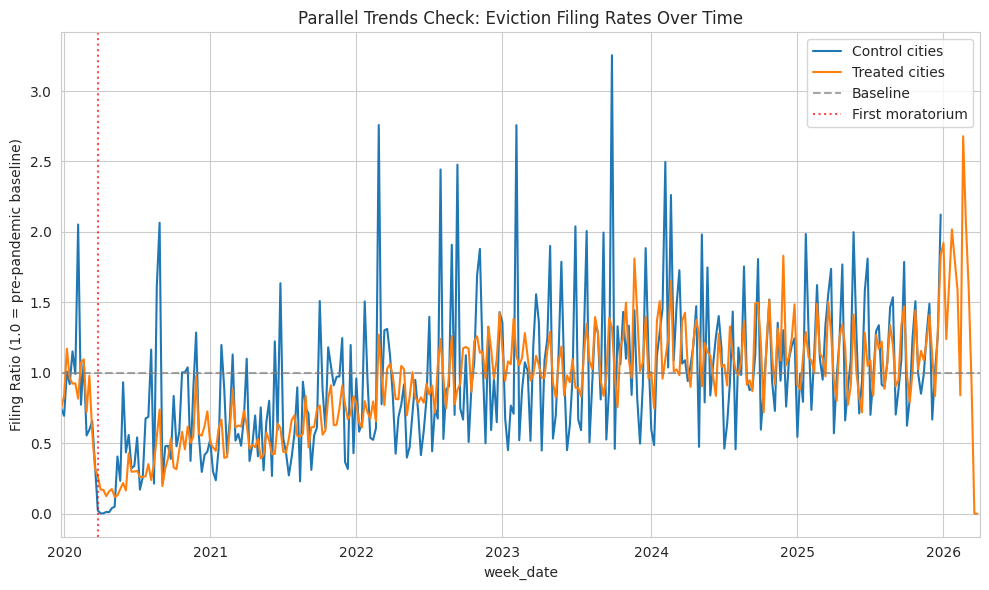

In [13]:
# --- Viz 1: Parallel Trends (the most important plot) ---
fig, ax = plt.subplots()
df_city.groupby(['week_date', 'ever_treated'])['filing_ratio'].mean().unstack().plot(ax=ax)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Historical baseline')
ax.axvline(pd.Timestamp('2020-03-27'), color='red', linestyle=':', alpha=0.7, label='First moratorium begins')
ax.set_title('Parallel Trends Check: Eviction Filing Rates Over Time')
ax.set_ylabel('Filing Ratio (1.0 = pre-pandemic baseline)')
ax.legend(['Control cities', 'Treated cities', 'Baseline', 'First moratorium'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_17679/2422540938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_city, x='moratorium', y='filing_ratio', palette='Set2')


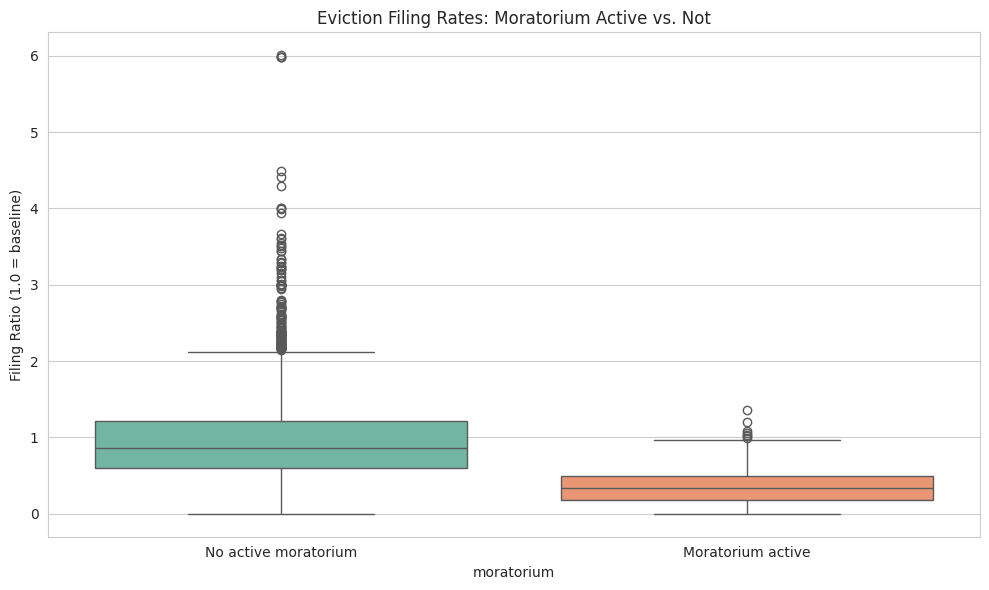

In [14]:
# --- Viz 2: Box plot — moratorium active vs. not ---
sns.boxplot(data=df_city, x='moratorium', y='filing_ratio', palette='Set2')
plt.xticks([0, 1], ['No active moratorium', 'Moratorium active'])
plt.title('Eviction Filing Rates: Moratorium Active vs. Not')
plt.ylabel('Filing Ratio (1.0 = baseline)')
plt.tight_layout()
plt.show()

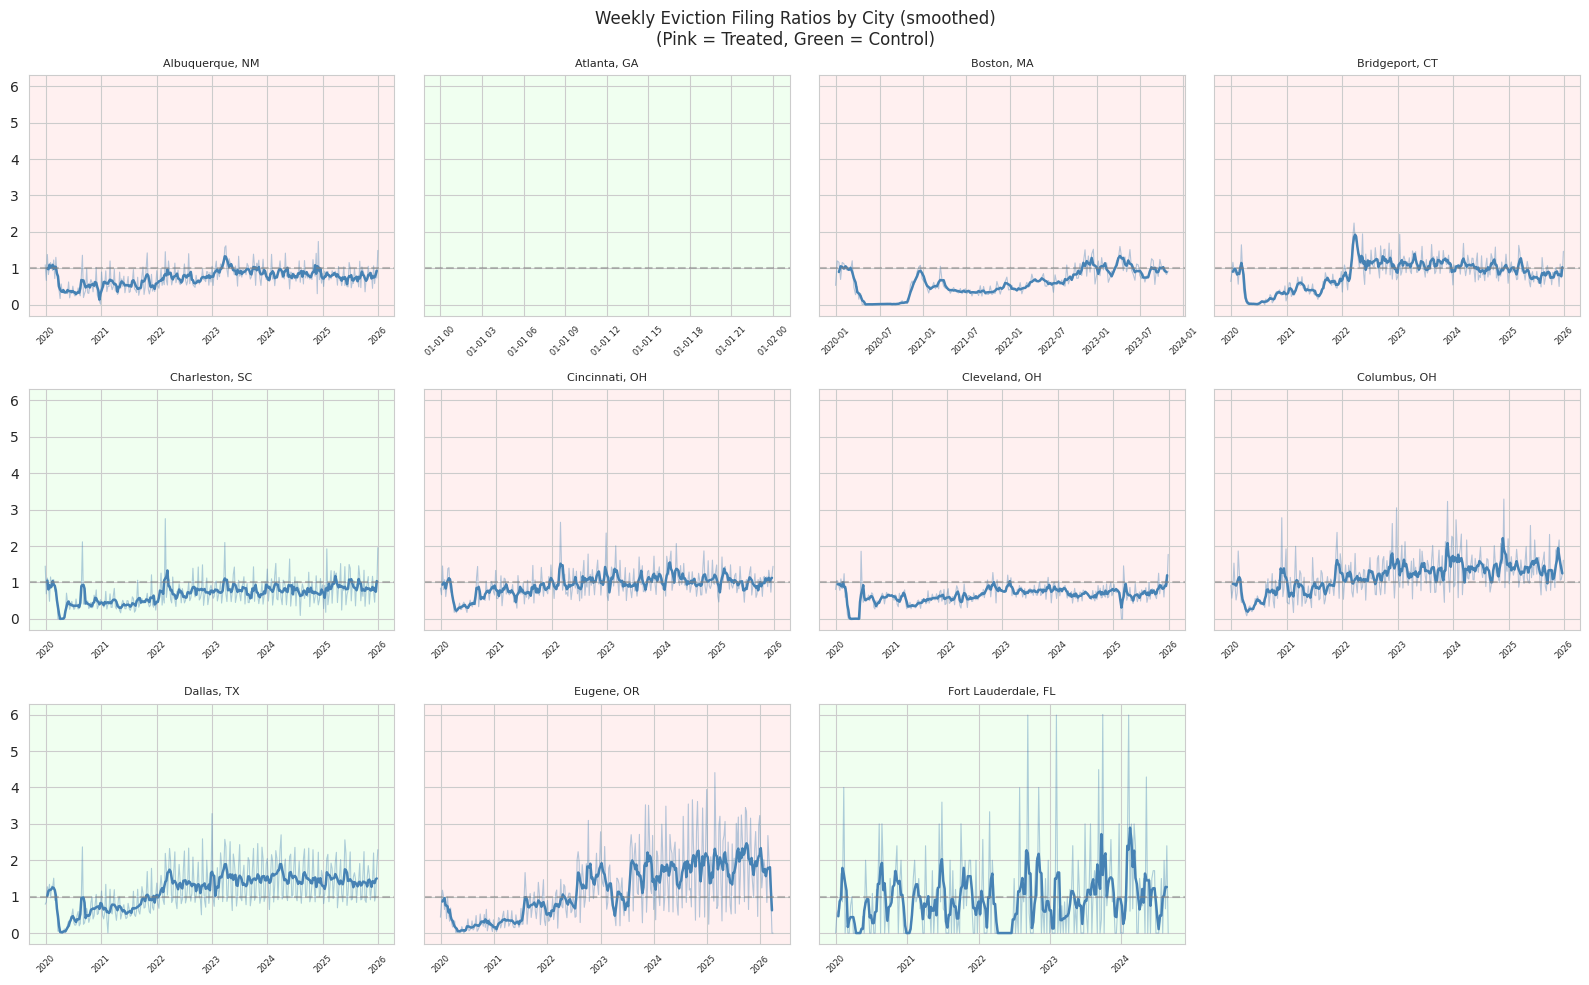

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=True)
axes = axes.flatten()

for i, city in enumerate(sorted(df_city['city'].unique())):
    city_df = df_city[df_city['city'] == city].sort_values('week_date')
    axes[i].plot(city_df['week_date'], city_df['filing_ratio'],
                 linewidth=0.8, alpha=0.4, color='steelblue')
    # 4-week rolling average
    axes[i].plot(city_df['week_date'],
                 city_df['filing_ratio'].rolling(4, center=True).mean(),
                 linewidth=1.8, color='steelblue')
    axes[i].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    axes[i].set_title(city, fontsize=8)
    axes[i].tick_params(axis='x', rotation=45, labelsize=6)
    treated = city_df['ever_treated'].iloc[0]
    axes[i].set_facecolor('#fff0f0' if treated else '#f0fff0')

for j in range(len(df_city['city'].unique()), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Weekly Eviction Filing Ratios by City (smoothed)\n(Pink = Treated, Green = Control)', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# --- Balance check ---
pre = df_city[df_city['week_date'] < '2020-03-01']
print("Pre-pandemic balance check:")
print(pre.groupby('ever_treated')[['filing_ratio']].agg(['mean', 'std']))

Pre-pandemic balance check:
             filing_ratio          
                     mean       std
ever_treated                       
0                1.046948  0.713807
1                0.950359  0.280380


In [18]:
print(df_city[df_city['city'] == 'Atlanta, GA'][['week_date', 'filing_ratio']].head(20))
print(df_city[df_city['city'] == 'Atlanta, GA']['week_date'].dtype)

     week_date  filing_ratio
328 2019-12-29           NaN
329 2020-01-05           NaN
330 2020-01-12           NaN
331 2020-01-19           NaN
332 2020-01-26           NaN
333 2020-02-02           NaN
334 2020-02-09           NaN
335 2020-02-16           NaN
336 2020-02-23           NaN
337 2020-03-01           NaN
338 2020-03-08           NaN
339 2020-03-15           NaN
340 2020-03-22           NaN
341 2020-03-29           NaN
342 2020-04-05           NaN
343 2020-04-12           NaN
344 2020-04-19           NaN
345 2020-04-26           NaN
346 2020-05-03           NaN
347 2020-05-10           NaN
datetime64[ns]


In [19]:
raw_atlanta = df[df['city'] == 'Atlanta, GA'][['filings_2020', 'filings_avg_prepandemic_baseline']].describe()
print(raw_atlanta)

        filings_2020  filings_avg_prepandemic_baseline
count  321233.000000                               0.0
mean        2.399831                               NaN
std         5.893956                               NaN
min         0.000000                               NaN
25%         0.000000                               NaN
50%         0.000000                               NaN
75%         2.000000                               NaN
max       254.000000                               NaN


In [20]:
df_city = df_city[df_city['city'] != 'Atlanta, GA'].copy()
df_city = df_city[df_city['city'] != 'Eugene, OR'].copy()

print(f"Remaining cities: {sorted(df_city['city'].unique())}")
print(f"Shape: {df_city.shape}")
print(f"Treated cities: {sorted(df_city[df_city['ever_treated']==1]['city'].unique())}")
print(f"Control cities: {sorted(df_city[df_city['ever_treated']==0]['city'].unique())}")

Remaining cities: ['Albuquerque, NM', 'Boston, MA', 'Bridgeport, CT', 'Charleston, SC', 'Cincinnati, OH', 'Cleveland, OH', 'Columbus, OH', 'Dallas, TX', 'Fort Lauderdale, FL']
Shape: (2742, 7)
Treated cities: ['Albuquerque, NM', 'Boston, MA', 'Bridgeport, CT', 'Cincinnati, OH', 'Cleveland, OH', 'Columbus, OH']
Control cities: ['Charleston, SC', 'Dallas, TX', 'Fort Lauderdale, FL']


In [21]:
print("Missing data summary:")
print(df_city.isnull().sum())
print(f"\nRows with missing filing_ratio: {df_city['filing_ratio'].isnull().sum()}")
print(f"Pct missing: {df_city['filing_ratio'].isnull().mean():.1%}")

# Drop NaNs for analysis
df_clean = df_city.dropna(subset=['filing_ratio']).copy()
print(f"\nClean dataset shape: {df_clean.shape}")

Missing data summary:
city                 0
week_date            0
filings_2020         0
filings_baseline     0
filing_ratio        98
moratorium           0
ever_treated         0
dtype: int64

Rows with missing filing_ratio: 98
Pct missing: 3.6%

Clean dataset shape: (2644, 7)


In [22]:
# --- Naive OLS ---
import statsmodels.api as sm

X_naive = sm.add_constant(df_clean[['moratorium']])
y = df_clean['filing_ratio']

naive_model = sm.OLS(y, X_naive).fit()
naive_est = naive_model.params['moratorium']
naive_ci = naive_model.conf_int().loc['moratorium'].values
print(f"Naive OLS estimate: {naive_est:.4f}")
print(f"95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}]")

Naive OLS estimate: -0.5527
95% CI: [-0.6196, -0.4858]


In [23]:
# --- TWFE DiD ---
import statsmodels.formula.api as smf

twfe = smf.ols(
    'filing_ratio ~ moratorium + C(city) + C(week_date)',
    data=df_clean
).fit(cov_type='HC1')  # heteroskedasticity-robust SEs

twfe_est = twfe.params['moratorium']
twfe_ci = twfe.conf_int().loc['moratorium'].values
print(f"DiD (TWFE) estimate: {twfe_est:.4f}")
print(f"95% CI: [{twfe_ci[0]:.4f}, {twfe_ci[1]:.4f}]")

DiD (TWFE) estimate: -0.0395
95% CI: [-0.1090, 0.0300]


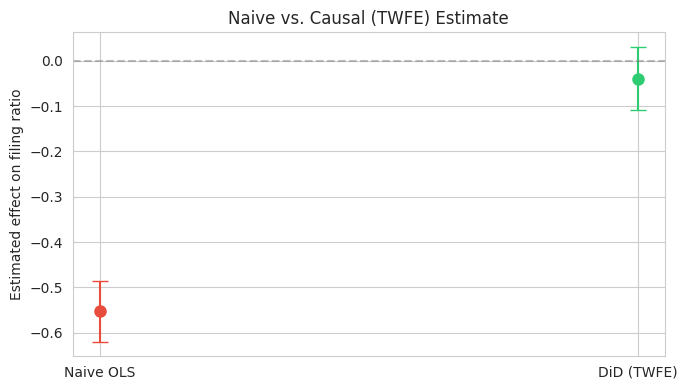

In [24]:
# --- Quick comparison plot ---
fig, ax = plt.subplots(figsize=(7, 4))
estimates = [naive_est, twfe_est]
cis = [naive_ci, twfe_ci]
labels = ['Naive OLS', 'DiD (TWFE)']
colors = ['#e74c3c', '#2ecc71']

for i, (est, ci, label, color) in enumerate(zip(estimates, cis, labels, colors)):
    ax.errorbar(i, est, yerr=[[est - ci[0]], [ci[1] - est]],
                fmt='o', color=color, capsize=6, markersize=8, label=label)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(labels)
ax.set_ylabel('Estimated effect on filing ratio')
ax.set_title('Naive vs. Causal (TWFE) Estimate')
plt.tight_layout()
plt.show()